Handwritten Digit Recognition

Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Data Preparation (Digits Dataset)

In [2]:
dataset = load_digits()
X = dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Features: {X_train.shape[1]}")
print(f"Total Classes: {len(np.unique(y))}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Features: 64
Total Classes: 10
Training samples: 1257
Testing samples: 540


Model Training and Comparison

In [3]:
models = {
    "Tiny (5, relu)": ((5,), 'relu'),
    "Small (10, relu)": ((10,), 'relu'),
    "Medium (32, 16, relu)": ((32, 16), 'relu'),
    "Complex (64, 32, 16, relu)": ((64, 32, 16), 'relu'),
    "Tanh (32, 16)": ((32, 16), 'tanh'),
    "Logistic (32, 16)": ((32, 16), 'logistic')
}

results = {}
best_acc = 0
best_name = ""
best_pred = None
best_model = None

print("-" * 50)

for name, (layers, act) in models.items():
    model = MLPClassifier(hidden_layer_sizes=layers, activation=act, max_iter=2000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name:30} : {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_name = name
        best_pred = y_pred
        best_model = model

print("-" * 50)

--------------------------------------------------
Tiny (5, relu)                 : 0.9241
Small (10, relu)               : 0.9685
Medium (32, 16, relu)          : 0.9685
Complex (64, 32, 16, relu)     : 0.9778
Tanh (32, 16)                  : 0.9778
Logistic (32, 16)              : 0.9611
--------------------------------------------------


Results Evaluation (Best Model)

In [4]:
print(f"Best Model Found: {best_name}")
print(f"Accuracy Score: {best_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Best Model Found: Complex (64, 32, 16, relu)
Accuracy Score: 0.9778

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      0.98      0.99        50
           2       0.96      1.00      0.98        47
           3       0.98      0.94      0.96        54
           4       0.97      1.00      0.98        60
           5       0.98      0.97      0.98        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.93      0.95      0.94        43
           9       0.97      0.97      0.97        59

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



Visualization (Confusion Matrix)

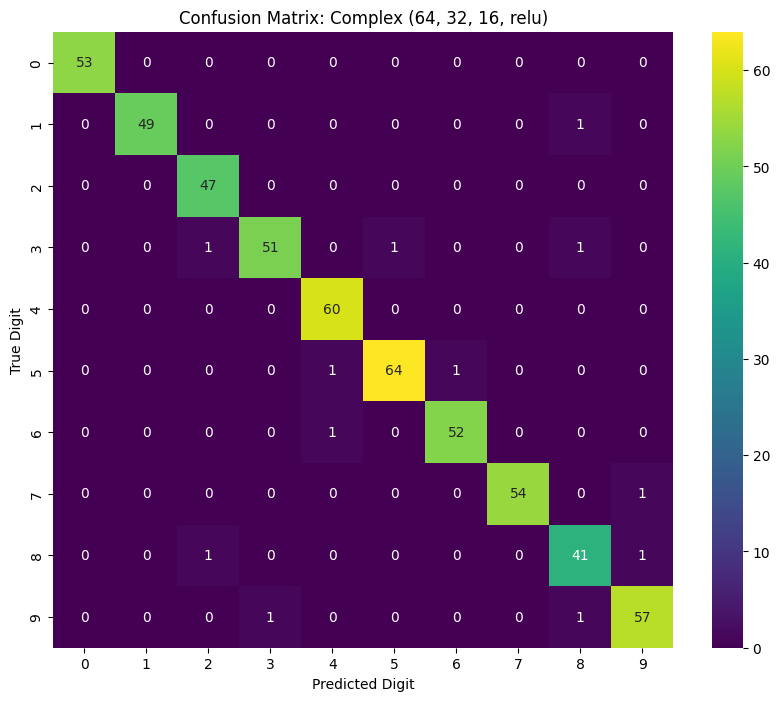

In [5]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=dataset.target_names,
            yticklabels=dataset.target_names)

plt.title(f"Confusion Matrix: {best_name}")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()